# K-Means on Full Data
**by Group 3**

## Installing and Importing Required Libraries

Install matplotlib for visualization

In [1]:
!pip install matplotlib

Java is installed for PySpark

In [2]:
!sudo yum install -y java-11-amazon-corretto-headless

Last metadata expiration check: 0:01:50 ago on Fri Jul 31 11:28:50 2026.
Dependencies resolved.
 Package                       Arch   Version                 Repository   Size
Installing:
 java-11-amazon-corretto-headless
                               x86_64 1:11.0.31+11-1.amzn2023 amazonlinux  91 M

Transaction Summary
Install  1 Package

Total download size: 91 M
Installed size: 226 M
java-11-amazon-corretto-headless-11.0.31+11-1.a  64 MB/s |  91 MB     00:01    
--------------------------------------------------------------------------------
Total                                            61 MB/s |  91 MB     00:01     
Running transaction check
Transaction check succeeded.
Running transaction test
Transaction test succeeded.
Running transaction
  Preparing        :                                                        1/1 
  Installing       : java-11-amazon-corretto-headless-1:11.0.31+11-1.amzn   1/1 
  Running scriptlet: java-11-amazon-corretto-headless-1:11.0.31+11-1.amzn   1

In [3]:
import os
import glob

# Search for the installed Java directory
java_paths = glob.glob('/usr/lib/jvm/java-11*')

if java_paths:
    # Dynamically set the environment variable to the found path
    os.environ["JAVA_HOME"] = java_paths[0]
    print(f"JAVA_HOME successfully set to: {os.environ['JAVA_HOME']}")
else:
    print("Java not found. Did the yum install command work?")

JAVA_HOME successfully set to: /usr/lib/jvm/java-11-amazon-corretto.x86_64


Importing the necessary libraries for the model training

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

Matplotlib is building the font cache; this may take a moment.


Setup a SparkSession

In [5]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark import StorageLevel
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

spark = (
    SparkSession.builder
    .appName("KMeans-Sample-Data")
    .master("local[*]")
    .config("spark.jars.packages",
            "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262")
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
    .config("spark.hadoop.fs.s3a.aws.credentials.provider",
            "com.amazonaws.auth.InstanceProfileCredentialsProvider")
    .config("spark.driver.memory", "10g")
    .getOrCreate()
)

INPUT_PATH = "s3a://dat204m-project-g3/cleaned_data_final/"
OUTPUT_PATH = "s3a://dat204m-project-g3/sampled_eda_data/"


print("Spark ready:", spark.version)

:: loading settings :: url = jar:file:/home/ec2-user/anaconda3/envs/pytorch/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.0.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/ec2-user/.ivy2/cache
The jars for the packages stored in: /home/ec2-user/.ivy2/jars
org.apache.hadoop#hadoop-aws added as a dependency
com.amazonaws#aws-java-sdk-bundle added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-f377a8df-3e41-447c-ae88-42ec14327f8f;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.3.4 in central
	found com.amazonaws#aws-java-sdk-bundle;1.12.262 in central
	found org.wildfly.openssl#wildfly-openssl;1.0.7.Final in central
downloading https://repo1.maven.org/maven2/org/apache/hadoop/hadoop-aws/3.3.4/hadoop-aws-3.3.4.jar ...
	[SUCCESSFUL ] org.apache.hadoop#hadoop-aws;3.3.4!hadoop-aws.jar (93ms)
downloading https://repo1.maven.org/maven2/com/amazonaws/aws-java-sdk-bundle/1.12.262/aws-java-sdk-bundle-1.12.262.jar ...
	[SUCCESSFUL ] com.amazonaws#aws-java-sdk-bundle;1.12.262!aws-java-sdk-bundle.jar (1282ms)
downloading https://repo1.maven.org/maven2/org/wildfly/openssl/wildfly-openssl/1.0.

26/07/31 11:31:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


Spark ready: 3.3.0


Check if connection to s3 is stable

In [6]:
import boto3

s3 = boto3.client("s3")

try:
    print(s3.list_objects_v2(Bucket="dat204m-project-g3", MaxKeys=5))
except Exception as e:
    print(e)

{'ResponseMetadata': {'RequestId': 'NH44KJ5J9B39AF8H', 'HostId': 'G/zyuxXsyMWIlmXlOe6cjqXzlymeM6dYlNTdo1IMw/v2VCe0Ahn0vxaerIPWFNL5Xc8V4siS/Eg=', 'HTTPStatusCode': 200, 'HTTPHeaders': {'x-amz-id-2': 'G/zyuxXsyMWIlmXlOe6cjqXzlymeM6dYlNTdo1IMw/v2VCe0Ahn0vxaerIPWFNL5Xc8V4siS/Eg=', 'x-amz-request-id': 'NH44KJ5J9B39AF8H', 'date': 'Fri, 31 Jul 2026 11:31:45 GMT', 'x-amz-bucket-region': 'us-east-1', 'content-type': 'application/xml', 'transfer-encoding': 'chunked', 'server': 'AmazonS3'}, 'RetryAttempts': 0}, 'IsTruncated': True, 'Contents': [{'Key': 'athena-logs/Unsaved/2026/07/05/0948405c-ddc7-4308-a5ea-9e4150ecd730-manifest.csv', 'LastModified': datetime.datetime(2026, 7, 4, 16, 28, 45, tzinfo=tzlocal()), 'ETag': '"c90c48a2b97547599fca337a336b68a1"', 'ChecksumAlgorithm': ['SHA1'], 'ChecksumType': 'FULL_OBJECT', 'Size': 3240, 'StorageClass': 'STANDARD'}, {'Key': 'athena-logs/Unsaved/2026/07/05/0948405c-ddc7-4308-a5ea-9e4150ecd730.metadata', 'LastModified': datetime.datetime(2026, 7, 4, 16, 28

## Reading and Standardizing Full Data

Read the Parquet file of the feature engineered full data

In [7]:
EDA_DATA_PATH = "s3a://dat204m-project-g3/feature_engineered_full/"
features_df = spark.read.parquet(EDA_DATA_PATH)

26/07/31 11:31:46 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties


Show the schema of the full data

In [8]:
features_df.printSchema()

root
 |-- product_id: string (nullable = true)
 |-- views: long (nullable = true)
 |-- likes: long (nullable = true)
 |-- cart: long (nullable = true)
 |-- offers: long (nullable = true)
 |-- buy_start: long (nullable = true)
 |-- buy_comp: long (nullable = true)
 |-- unique_users: long (nullable = true)
 |-- unique_sessions: long (nullable = true)
 |-- avg_price: double (nullable = true)
 |-- brand_name: string (nullable = true)
 |-- category_path: string (nullable = true)
 |-- cond_good: long (nullable = true)
 |-- cond_new: long (nullable = true)
 |-- cond_like_new: long (nullable = true)
 |-- cond_fair: long (nullable = true)
 |-- cond_poor: long (nullable = true)
 |-- cond_unknown: long (nullable = true)
 |-- log_views: double (nullable = true)
 |-- log_likes: double (nullable = true)
 |-- log_cart: double (nullable = true)
 |-- log_offers: double (nullable = true)
 |-- log_buy_start: double (nullable = true)
 |-- log_buy_comp: double (nullable = true)
 |-- log_users: double (null

Show the first five lines of the full data

In [9]:
features_df.show(5)

26/07/31 11:31:51 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


[Stage 1:>                                                          (0 + 1) / 1]

+----------+-----+-----+----+------+---------+--------+------------+---------------+------------------+--------------+--------------------+---------+--------+-------------+---------+---------+------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+-----------------+------------------+------------------+------------------+-------------+----------------+
|product_id|views|likes|cart|offers|buy_start|buy_comp|unique_users|unique_sessions|         avg_price|    brand_name|       category_path|cond_good|cond_new|cond_like_new|cond_fair|cond_poor|cond_unknown|         log_views|         log_likes|          log_cart|        log_offers|     log_buy_start|      log_buy_comp|         log_users|      log_sessions|        log_price|    log_cond_good|      log_cond_new| log_cond_like_new|     log_cond_fair|log_cond_poor|log_cond_unknown|
+----------+-----+-----+----+------+

To reduce recomputation and improve performance, DataFrame is cached in memory and spills excess data to disk when needed

In [10]:
features_df = features_df.persist(StorageLevel.MEMORY_AND_DISK)

In [11]:
# Materialize cache
features_df.count()

1383996

Frequency Encoding is applied for categorical columns 'brand_name' and 'category_path' 

In [12]:
freq_cols = [
    "brand_name",
    "category_path"
]

features_encoded = features_df

for c in freq_cols:
    freq = (
        features_df.groupBy(c)
                   .count()
                   .withColumnRenamed("count", f"{c}_freq")
    )

    features_encoded = (
        features_encoded
        .join(freq, on=c, how="left")
    )

All numerical columns are combined into one single feature vector using VectorAssembler

In [13]:
numeric_features = [
    "log_views",
    "log_likes",
    "log_cart",
    "log_offers",
    "log_buy_comp",
    "log_buy_start",
    "log_users",
    "log_sessions",
    "log_price",
    "brand_name_freq",
    "category_path_freq",
    "log_cond_good",
    "log_cond_new",
    "log_cond_like_new",
    "log_cond_fair",
    "log_cond_poor",
    "log_cond_unknown"
]

assembler = VectorAssembler(
    inputCols=numeric_features,
    outputCol="features_raw"
)

Standard scaling is applied to prevent features with larger numerical ranges from dominating the clustering process

In [14]:
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=False,
    withStd=True
)

Pipeline is run to apply the vectorizing and standard scaling to the full data

In [15]:
pipeline = Pipeline(stages=[
    assembler,
    scaler
])

In [16]:
pipeline_model = pipeline.fit(features_encoded)

In [17]:
kmeans_df = pipeline_model.transform(features_encoded)

## Initial Model Training

As we do not have any target data, we will be doing unsupervised modelling with KMeans

Initialize a KMeans model

In [18]:
kmeans = KMeans(
    featuresCol="features",
    predictionCol="cluster",
    k=10,
    seed=42
)

Fit the model to the data

In [19]:
model = kmeans.fit(kmeans_df)

Assign each product to its predicted cluster

In [20]:
clustered_products = model.transform(kmeans_df)

Evaluation Metrics used for KMeans are the following:

* Silhouette Score - Evaluates the similarity of an object to its own group relative to other groups, thereby reflecting the balance between cohesion and separation
* Davies-Bouldin Index - Quantifies group compactness and separation. A lower index signifies higher-quality clusters.
* Calinski–Harabasz Index - Used to compare different clustering results and help select the optimal number of clusters. A higher score indicates better-defined clusters with greater separation between clusters and higher compactness within clusters.

Based on Alshrouf, F., Masadeh, S., Al-Fraihat, D., & Al-Nsoor, R. (2025). Improving BIRCH hierarchical clustering algorithms for enhanced partitioning of medical data. Cluster Computing, 28(9), 600.

In [21]:
pdf = clustered_products.select("features", "cluster").toPandas()

X = np.vstack(pdf["features"].apply(lambda x: x.toArray()))
labels = pdf["cluster"].values

silhouette = silhouette_score(
    X,
    labels,
    sample_size=20000,
    random_state=42
)

dbi = davies_bouldin_score(X, labels)
chi = calinski_harabasz_score(X, labels)

print(f"Silhouette Score:        {silhouette:.4f}")
print(f"Davies-Bouldin Index:   {dbi:.4f}")
print(f"Calinski-Harabasz Index:{chi:.4f}")

Silhouette Score:        0.1836
Davies-Bouldin Index:   1.4341
Calinski-Harabasz Index:323824.8519


## Hyperparameter Tuning

We check which available hyperparameters can be changed

In [22]:
kmeans = KMeans()

print(kmeans.explainParams())

distanceMeasure: the distance measure. Supported options: 'euclidean' and 'cosine'. (default: euclidean)
featuresCol: features column name. (default: features)
initMode: The initialization algorithm. This can be either "random" to choose random points as initial cluster centers, or "k-means||" to use a parallel variant of k-means++ (default: k-means||)
initSteps: The number of steps for k-means|| initialization mode. Must be > 0. (default: 2)
k: The number of clusters to create. Must be > 1. (default: 2)
maxIter: max number of iterations (>= 0). (default: 20)
predictionCol: prediction column name. (default: prediction)
seed: random seed. (default: 4226294873962467018)
tol: the convergence tolerance for iterative algorithms (>= 0). (default: 0.0001)
weightCol: weight column name. If this is not set or empty, we treat all instance weights as 1.0. (undefined)


The selected hyperparameters to change are:
* K
* maxIter
* initMode
* initSteps

Based on Gikera, R., Mwaura, J., Muuro, E., & Mambo, S. K-Hyperparameter Tuning in High-Dimensional Space Clustering: Solving Smooth Elbow Challenges Using an Ensemble Based Technique of a Self-Adapting Autoencoder and Internal Validation Indexes.

In [23]:
# Hyperparameter values
k_values = [5, 8, 10, 12, 15]
maxIter_values = [20, 50]
initMode_values = ["k-means||", "random"]
initSteps_values = [2, 5, 10]

Silhouette evaluator from PySpark is used as evaluator for Hyperparameter tuning as it has efficient evaluation directly on Spark DataFrames without collecting large datasets into driver memory

In [24]:
evaluator = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="cluster",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

For every iteration, we will:

1. Set the KMeans model parameters using the current hyperparameter combination
2. Train the model to the dataset
3. Generate cluster predictions
4. Evaluate the model using the Silhouette Score
5. Record the hyperparameter combination and evaluation result
6. Keep track of the best-performing model and its corresponding hyperparameters based on the highest Silhouette Score

In [25]:
results = []
best_score = -1
best_model = None
best_params = None

for k in k_values:
    for maxIter in maxIter_values:
        for initMode in initMode_values:
            for initSteps in initSteps_values:

                kmeans = KMeans(
                    featuresCol="features",
                    predictionCol="cluster",
                    k=k,
                    maxIter=maxIter,
                    initMode=initMode,
                    initSteps=initSteps,
                    seed=42
                )

                model = kmeans.fit(kmeans_df)

                predictions = model.transform(kmeans_df)

                silhouette = evaluator.evaluate(predictions)

                results.append({
                    "k": k,
                    "maxIter": maxIter,
                    "initMode": initMode,
                    "initSteps": initSteps,
                    "silhouette": silhouette
                })

                print(
                    f"k={k:2d}, "
                    f"maxIter={maxIter:3d}, "
                    f"initMode={initMode:10s}, "
                    f"initSteps={initSteps:2d}, "
                    f"Silhouette={silhouette:.4f}"
                )

                if silhouette > best_score:
                    best_score = silhouette
                    best_model = model
                    best_params = {
                        "k": k,
                        "maxIter": maxIter,
                        "initMode": initMode,
                        "initSteps": initSteps
                    }

print("\nBest Hyperparameters")
print(best_params)
print(f"Best Silhouette Score: {best_score:.4f}")

k= 5, maxIter= 20, initMode=k-means|| , initSteps= 2, Silhouette=0.3265


k= 5, maxIter= 20, initMode=k-means|| , initSteps= 5, Silhouette=0.4007


k= 5, maxIter= 20, initMode=k-means|| , initSteps=10, Silhouette=0.2728


k= 5, maxIter= 20, initMode=random    , initSteps= 2, Silhouette=0.2710


k= 5, maxIter= 20, initMode=random    , initSteps= 5, Silhouette=0.2710


...

k=15, maxIter= 50, initMode=k-means|| , initSteps=10, Silhouette=0.2181


k=15, maxIter= 50, initMode=random    , initSteps= 2, Silhouette=0.2358


k=15, maxIter= 50, initMode=random    , initSteps= 5, Silhouette=0.2358


[Stage 9876:============================>                           (4 + 4) / 8]

k=15, maxIter= 50, initMode=random    , initSteps=10, Silhouette=0.2358

Best Hyperparameters
{'k': 5, 'maxIter': 50, 'initMode': 'k-means||', 'initSteps': 5}
Best Silhouette Score: 0.4066


## Train the Final Model

The best parameter is

{'k': 5, 'maxIter': 50, 'initMode': 'k-means||', 'initSteps': 5}

Train the final model with the best parameter

In [18]:
final_kmeans = KMeans(
    featuresCol="features",
    predictionCol="cluster",
    k=5,
    maxIter=50,
    initMode="k-means||",
    initSteps=5
)

In [19]:
final_model = final_kmeans.fit(kmeans_df)

In [20]:
clustered_products = final_model.transform(kmeans_df)

Using Sklearn's Silhouette Score, Davies-Bouldin Index (DBI), Calinski-Harabasz Index (CHI), evaluate the model

Silhouette Score used a 20,000-sample subset to reduce computation from pairwise distance calculations while maintaining a reliable estimate. DBI and CHI were calculated on the full dataset due to their lower computational cost.

In [21]:
pdf = clustered_products.select("features", "cluster").toPandas()

X = np.vstack(pdf["features"].apply(lambda x: x.toArray()))
labels = pdf["cluster"].values

silhouette = silhouette_score(
    X,
    labels,
    sample_size=20000,
    random_state=42
)

dbi = davies_bouldin_score(X, labels)
chi = calinski_harabasz_score(X, labels)

print(f"Silhouette Score:       {silhouette:.4f}")
print(f"Davies-Bouldin Index:   {dbi:.4f}")
print(f"Calinski-Harabasz Index:{chi:.4f}")

Silhouette Score:       0.1692
Davies-Bouldin Index:   1.6758
Calinski-Harabasz Index:468137.6942


Check the rate for each condition in the clusters

In [23]:
clustered_products = clustered_products.withColumn(
    "total_conditions",
    F.col("cond_good") +
    F.col("cond_new") +
    F.col("cond_like_new") +
    F.col("cond_fair") +
    F.col("cond_poor") +
    F.col("cond_unknown")
)

In [24]:
clustered_products = (
    clustered_products
    .withColumn(
        "new_rate",
        F.when(
            F.col("total_conditions") > 0,
            F.col("cond_new") / F.col("total_conditions")
        ).otherwise(0)
    )
    .withColumn(
        "like_new_rate",
        F.when(
            F.col("total_conditions") > 0,
            F.col("cond_like_new") / F.col("total_conditions")
        ).otherwise(0)
    )
    .withColumn(
        "good_rate",
        F.when(
            F.col("total_conditions") > 0,
            F.col("cond_good") / F.col("total_conditions")
        ).otherwise(0)
    )
    .withColumn(
        "fair_rate",
        F.when(
            F.col("total_conditions") > 0,
            F.col("cond_fair") / F.col("total_conditions")
        ).otherwise(0)
    )
    .withColumn(
        "poor_rate",
        F.when(
            F.col("total_conditions") > 0,
            F.col("cond_poor") / F.col("total_conditions")
        ).otherwise(0)
    )
    .withColumn(
        "unknown_rate",
        F.when(
            F.col("total_conditions") > 0,
            F.col("cond_unknown") / F.col("total_conditions")
        ).otherwise(0)
    )
)

Check the summary per each cluster

In [25]:
cluster_summary = (
    clustered_products
    .groupBy("cluster")
    .agg(
        # Cluster size
        F.count("*").alias("num_products"),

        # Customer engagement
        F.round(F.avg("views"), 2).alias("avg_views"),
        F.round(F.avg("likes"), 2).alias("avg_likes"),
        F.round(F.avg("cart"), 2).alias("avg_cart"),
        F.round(F.avg("buy_comp"), 2).alias("avg_purchases"),

        # Customer reach
        F.round(F.avg("unique_users"), 2).alias("avg_unique_users"),
        F.round(F.avg("unique_sessions"), 2).alias("avg_unique_sessions"),

        # Product characteristics
        F.round(F.avg("avg_price"), 2).alias("avg_price"),

        # Condition profile
        F.round(F.avg("new_rate"), 3).alias("pct_new"),
        F.round(F.avg("like_new_rate"), 3).alias("pct_like_new"),
        F.round(F.avg("good_rate"), 3).alias("pct_good"),
        F.round(F.avg("fair_rate"), 3).alias("pct_fair"),
        F.round(F.avg("poor_rate"), 3).alias("pct_poor"),
        F.round(F.avg("unknown_rate"), 3).alias("pct_unknown")
    )
    .orderBy("cluster")
)

cluster_summary.show(truncate=False)

[Stage 314:==============>                                          (1 + 3) / 4]

+-------+------------+---------+---------+--------+-------------+----------------+-------------------+---------+-------+------------+--------+--------+--------+-----------+
|cluster|num_products|avg_views|avg_likes|avg_cart|avg_purchases|avg_unique_users|avg_unique_sessions|avg_price|pct_new|pct_like_new|pct_good|pct_fair|pct_poor|pct_unknown|
+-------+------------+---------+---------+--------+-------------+----------------+-------------------+---------+-------+------------+--------+--------+--------+-----------+
|0      |571592      |5.01     |0.46     |0.05    |0.01         |4.36            |4.91               |21.73    |0.357  |0.258       |0.359   |0.024   |0.003   |0.0        |
|1      |436302      |28.56    |2.76     |0.22    |0.03         |22.98           |27.71              |71.98    |0.351  |0.242       |0.383   |0.022   |0.003   |0.0        |
|2      |17477       |42671.8  |7923.18  |874.13  |48.89        |11643.29        |32094.01           |60.83    |0.342  |0.233       |0.

The cluster distribution shows varying levels of customer engagement across the five product segments. **Cluster 0** is the largest group with **762,157 products**, representing **low-engagement products** with the lowest averages for views, likes, carts, purchases, unique users, and sessions. **Cluster 2** is the second largest cluster (**411,488 products**) and consists of **moderately engaged products**, exhibiting higher customer interactions than Clusters 0 and 1. **Cluster 4** (**119,391 products**) represents **high-engagement products**, recording substantially higher averages across all engagement metrics while remaining far below the extreme values of Cluster 3.

**Cluster 1** (**68,856 products**) forms a **medium-engagement segment**, with customer interactions greater than Cluster 0 but lower than Clusters 2 and 4. In contrast, **Cluster 3** is the smallest cluster (**22,104 products**) yet stands out as an **exceptional high-engagement segment**, recording extremely high averages for views, likes, carts, purchases, unique users, and sessions. This suggests that Cluster 3 contains a small number of highly popular or viral products that receive significantly more customer attention than all other clusters.

Overall, the clusters are primarily differentiated by **customer engagement intensity**, ranging from low-engagement products (Cluster 0) to exceptionally high-engagement products (Cluster 3), while product condition remains relatively similar across all clusters.

In [26]:
from pyspark.sql.window import Window

# Count products in each category path within each cluster
category_counts = (
    clustered_products
    .groupBy("cluster", "category_path")
    .count()
)

# Rank category paths within each cluster
window = Window.partitionBy("cluster").orderBy(F.desc("count"))

top10_category_paths = (
    category_counts
    .withColumn("rank", F.row_number().over(window))
    .filter(F.col("rank") <= 10)
    .orderBy("cluster", "rank")
)

top10_category_paths.show(100, truncate=False)

[Stage 326:>                                                        (0 + 4) / 4]

+-------+-------------------------------------------------------------------+-----+----+
|cluster|category_path                                                      |count|rank|
+-------+-------------------------------------------------------------------+-----+----+
|0      |Women > Tops & blouses > Blouse                                    |3146 |1   |
|0      |Women > Tops & blouses > T-shirts                                  |3113 |2   |
|0      |Women > Other > Other                                              |3029 |3   |
|0      |Other > Other > Other                                              |2973 |4   |
|0      |Men > Tops > T-shirts                                              |2494 |5   |
|0      |Women > Tops & blouses > Tops & blouses                            |2410 |6   |
|0      |Vintage & collectibles > Antique > Collectibles                    |2404 |7   |
|0      |Home > Home decor > Home decor accents                             |2180 |8   |
|0      |Women > Dres

The category distribution analysis shows that **fashion-related products dominate most clusters**, particularly women's apparel such as tops, blouses, and dresses. This reflects the overall marketplace trend where clothing represents a major portion of product listings.

**Cluster 0** contains a broad mix of marketplace products, with the most frequent categories being women's tops, men's t-shirts, and general categories. The presence of categories such as *Other > Other* and collectibles suggests that this cluster represents a diverse product segment rather than a specific product niche.

**Cluster 1** is mainly composed of fashion and lifestyle products, with women's coats, dresses, and home decor appearing among the top categories. This indicates a stronger concentration of apparel and lifestyle-related products compared to other clusters.

**Cluster 2** shows a different product composition from the other clusters, with **toys and collectibles, beauty products, and footwear** appearing as major categories. The presence of action figures and collectible items suggests that this cluster captures more niche product interests.

**Cluster 3** is strongly dominated by women's fashion categories, especially blouses, t-shirts, tank tops, and dresses. This indicates that this segment primarily represents apparel-focused products.

**Cluster 4** also shows a strong concentration in women's fashion, particularly tops, dresses, and shoes. Compared to other clusters, this segment appears to be centered around core fashion categories.

Overall, the category analysis indicates that **most clusters are driven by fashion products**, while **Cluster 2 stands out due to its higher representation of niche categories such as collectibles and beauty products**. These differences suggest that product category composition may contribute to variations in customer engagement and product performance across clusters.

In [27]:
from pyspark.sql.window import Window

# Count products for each brand within each cluster
brand_counts = (
    clustered_products
    .groupBy("cluster", "brand_name")
    .count()
)

# Rank brands within each cluster
window = Window.partitionBy("cluster").orderBy(F.desc("count"))

top10_brands = (
    brand_counts
    .withColumn("rank", F.row_number().over(window))
    .filter(F.col("rank") <= 10)
    .select("cluster", "rank", "brand_name", "count")
    .orderBy("cluster", "rank")
)

top10_brands.show(100, truncate=False)

[Stage 345:>                                                        (0 + 4) / 4]

+-------+----+--------------------------------+-----+
|cluster|rank|brand_name                      |count|
+-------+----+--------------------------------+-----+
|0      |1   |Walmart                         |446  |
|0      |2   |The Unbranded Brand             |416  |
|0      |3   |Abbott                          |400  |
|0      |4   |ABC Studios                     |389  |
|0      |5   |Amazon                          |380  |
|0      |6   |AA Aquarium                     |379  |
|0      |7   |Independent                     |378  |
|0      |8   |Target                          |374  |
|0      |9   |Avon                            |371  |
|0      |10  |Custom Variety Pack             |348  |
|1      |1   |Unique Vintage                  |459  |
|1      |2   |The Unbranded Brand             |422  |
|1      |3   |Authentic Original Vintage Style|390  |
|1      |4   |Customized & Personalized       |373  |
|1      |5   |American Vintage                |350  |
|1      |6   |Sears         

The brand distribution analysis shows that **clusters contain a wide variety of brands**, with no single brand dominating across all segments. This suggests that product engagement differences are likely influenced by a combination of factors such as product type, demand, and customer interest rather than brand alone.

**Cluster 0** contains a diverse range of mainstream and general brands, including Walmart, Amazon, Target, and unbranded products. The presence of large retailers and generic brands suggests that this cluster represents a broad marketplace segment with products from various sources.

**Cluster 1** shows a stronger presence of vintage and fashion-related brands, such as Unique Vintage, American Vintage, and boutique brands. This indicates that this cluster is more associated with fashion-oriented and vintage product segments.

**Cluster 2** has a distinct brand profile, with Disney, Nike, Sanrio, Adidas, and lululemon appearing among the top brands. These recognizable brands suggest that this cluster contains products with stronger brand identity and niche customer interest.

**Cluster 3** contains a mixture of major retailers and character-based brands, including Amazon, Disney, Target, Sanrio, and Hello Kitty. The combination of retail and collectible brands indicates a diverse product segment with broad customer appeal.

**Cluster 4** is dominated by unbranded and handmade products, with brands such as Disney, Amazon, Sanrio, and Boutique also appearing frequently. This suggests that this cluster includes a mix of independent sellers and recognizable consumer brands.

Overall, the brand analysis indicates that **brand presence varies across clusters, but highly recognizable brands and niche brands appear more frequently in some segments**. In particular, Cluster 2 stands out due to the presence of strong identity brands such as Disney, Nike, Adidas, and Sanrio, which may contribute to higher customer interest and engagement.

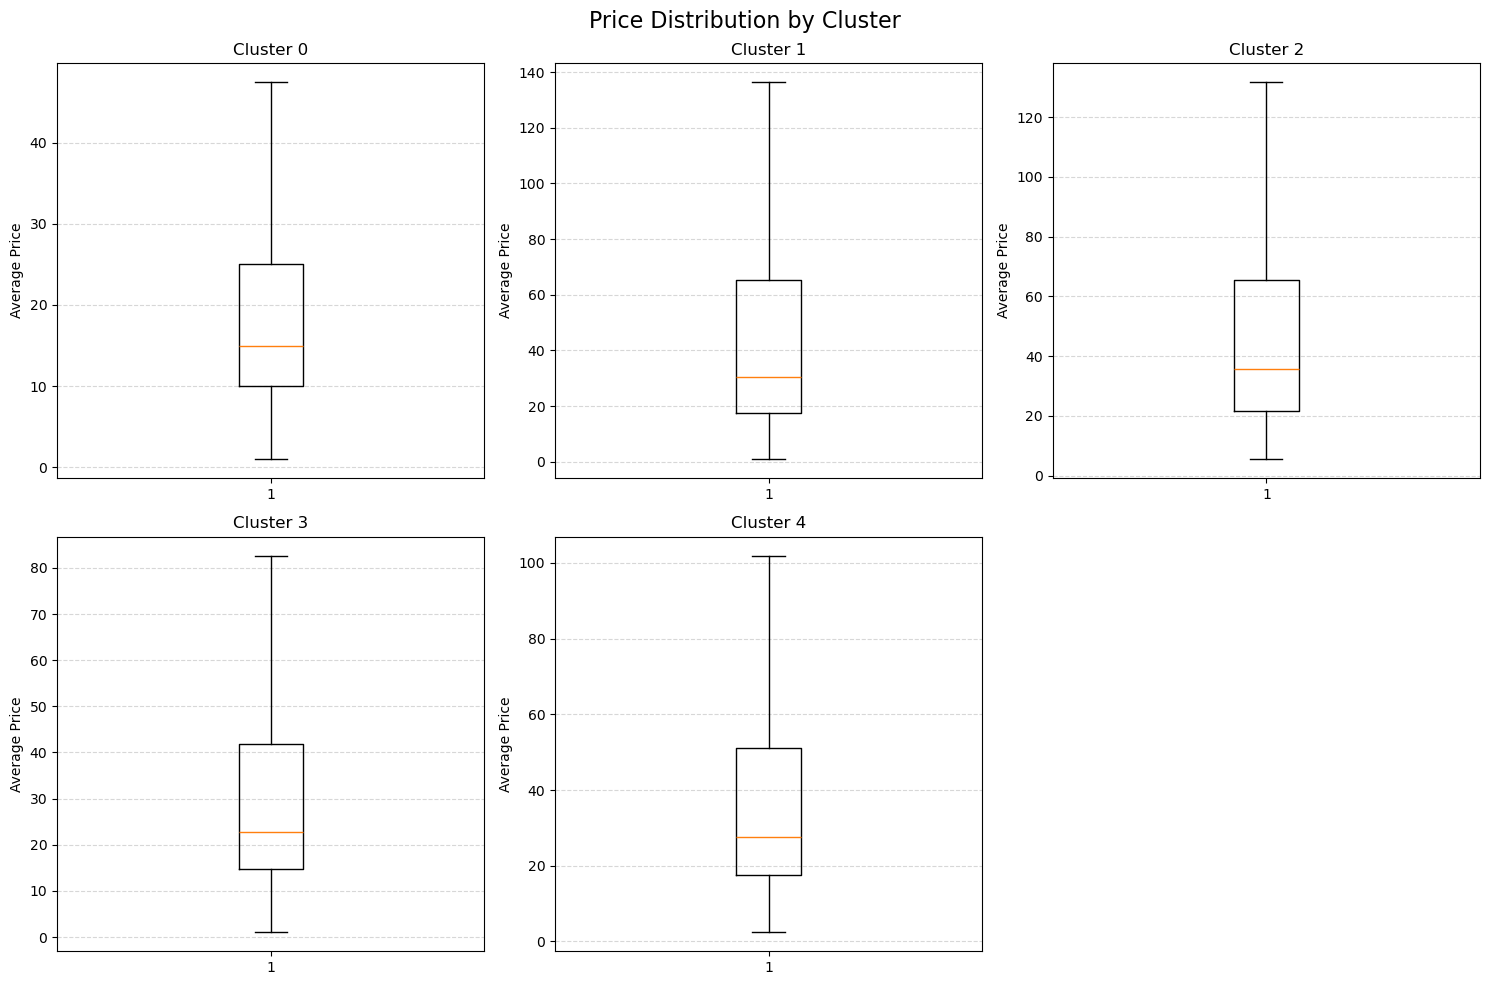

In [32]:
price_df = (
    clustered_products
    .select("cluster", "avg_price")
    .toPandas()
)

clusters = sorted(price_df["cluster"].unique())

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, cluster in enumerate(clusters):
    cluster_prices = price_df.loc[
        price_df["cluster"] == cluster,
        "avg_price"
    ].dropna()

    axes[i].boxplot(cluster_prices, showfliers=False)
    axes[i].set_title(f"Cluster {cluster}")
    axes[i].set_ylabel("Average Price")
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)

# Hide the unused subplot (6th)
if len(clusters) < len(axes):
    for j in range(len(clusters), len(axes)):
        axes[j].axis("off")

plt.suptitle("Price Distribution by Cluster", fontsize=16)
plt.tight_layout()
plt.show()

The price distribution across clusters shows that **average price differs between product segments**, but price alone does not fully explain product performance. Highly engaged clusters do not necessarily have the highest prices, suggesting that customer interest is influenced by other factors such as product category, brand, and demand.

**Cluster 0** shows the lowest price distribution, with most products concentrated in the lower price range. This suggests that this cluster contains more affordable products and may represent a broader marketplace segment.

**Cluster 1** has a higher price range compared to Cluster 0, indicating that products in this cluster are generally more expensive. However, higher prices do not directly correspond to higher engagement.

**Cluster 2** has the highest price distribution among the clusters, with products generally positioned at a higher price range. Combined with its strong engagement performance, this suggests that customers are willing to interact with higher-value products when there is strong demand or product appeal.

**Cluster 3** shows a moderate price distribution, with products generally positioned in the mid-price range. This aligns with its moderate engagement behavior.

**Cluster 4** has a wider price range, covering both affordable and higher-priced products. This indicates a diverse product segment with varying price levels.

Overall, the price analysis suggests that **product success is not determined by price alone**. While some high-performing products have higher prices, customer engagement appears to be influenced by a combination of product popularity, category, and brand factors.

## Supporting Visualizations

In [28]:
cluster_summary_pdf = cluster_summary.toPandas()

The engagement metrics reveal a clear separation among the clusters. **Cluster 3** exhibits exceptionally high average views, likes, carts, and purchases, making it a distinct group of **highly popular products**. **Cluster 4** records the second-highest engagement across all metrics, representing **high-engagement products**. **Cluster 2** shows **moderate engagement**, followed by **Cluster 1**, while **Cluster 0** consistently records the lowest averages, indicating **low-engagement products**. Overall, the clusters represent a progression from low- to exceptionally high-engagement product segments.

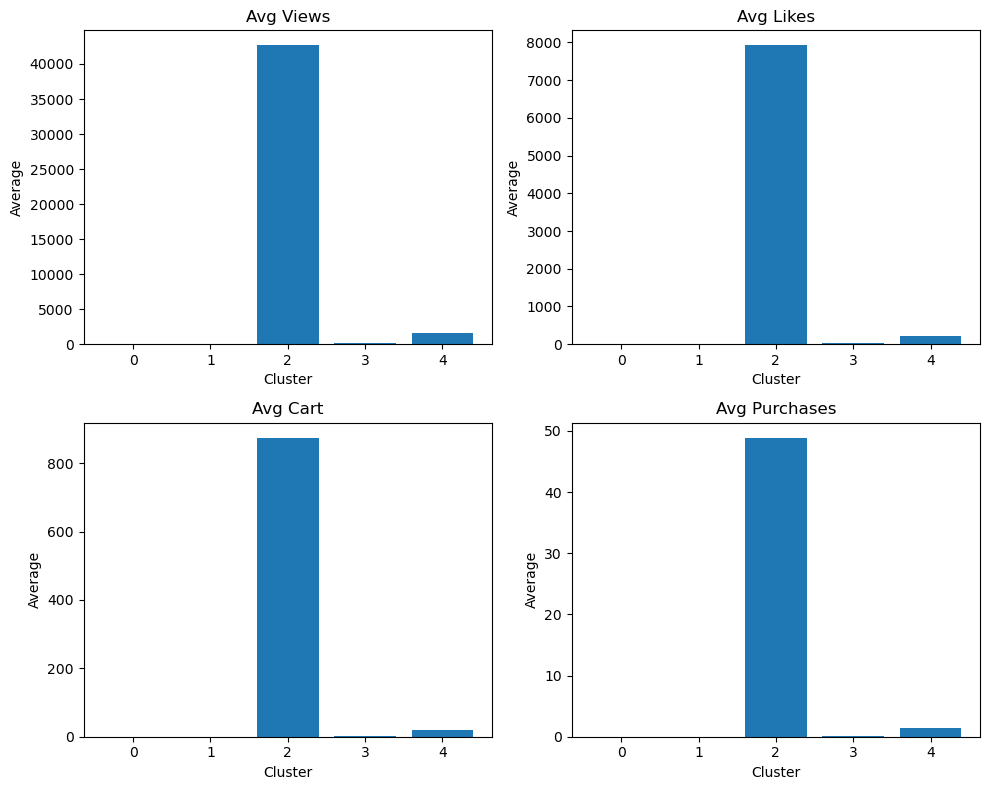

In [29]:
features = ["avg_views", "avg_likes", "avg_cart", "avg_purchases"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    ax.bar(cluster_summary_pdf["cluster"].astype(str), cluster_summary_pdf[feature])
    ax.set_title(feature.replace("_", " ").title())
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Average")

plt.tight_layout()
plt.show()

The normalized heatmap clearly distinguishes the five clusters based on their relative feature values. **Cluster 3** exhibits the **highest normalized values across all customer engagement metrics**, indicating an exceptional high-engagement segment. **Cluster 4** also demonstrates **strong engagement**, though at lower levels than Cluster 3, while **Cluster 2** is characterized by a **higher average price** despite only moderate engagement. **Clusters 0 and 1** show the **lowest normalized engagement values**, representing products with relatively limited customer interaction. Overall, the heatmap confirms that the clusters are primarily differentiated by **customer engagement intensity**, with price contributing mainly to the distinction of Cluster 2.

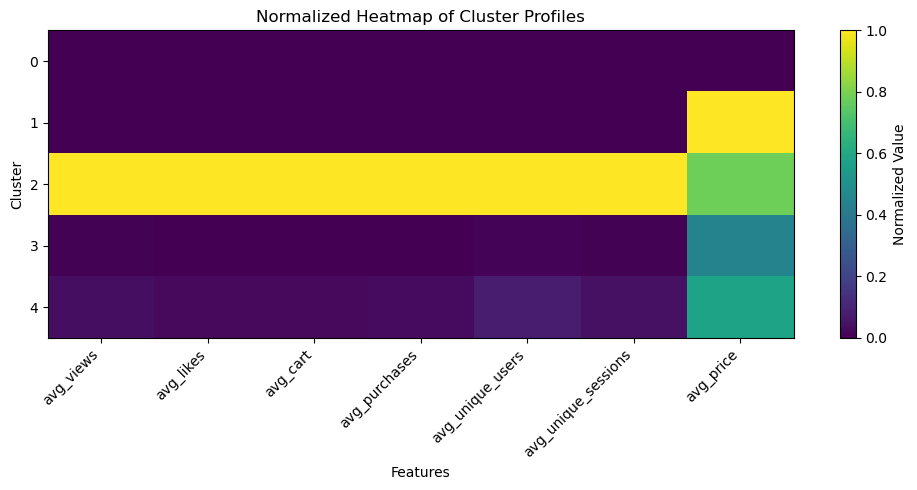

In [30]:
pdf = cluster_summary.select(
    "cluster",
    "avg_views",
    "avg_likes",
    "avg_cart",
    "avg_purchases",
    "avg_unique_users",
    "avg_unique_sessions",
    "avg_price"
).toPandas().sort_values("cluster")

data = pdf.set_index("cluster")

# Normalize each feature to [0, 1]
scaler = MinMaxScaler()
normalized = scaler.fit_transform(data)

plt.figure(figsize=(10, 5))

plt.imshow(normalized, aspect="auto")

plt.colorbar(label="Normalized Value")

plt.xticks(
    range(len(data.columns)),
    data.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(data.index)),
    data.index
)

plt.xlabel("Features")
plt.ylabel("Cluster")
plt.title("Normalized Heatmap of Cluster Profiles")

plt.tight_layout()
plt.show()

The PCA projection shows that the clusters are **reasonably well separated**, although some overlap exists among the lower-engagement groups. **Cluster 3** is the most distinct, extending far from the other clusters along the principal components, indicating products with exceptionally high customer engagement. **Clusters 0, 2, and 4** form more compact groups with moderate overlap, while **Cluster 1** is positioned between the low- and high-engagement segments. 

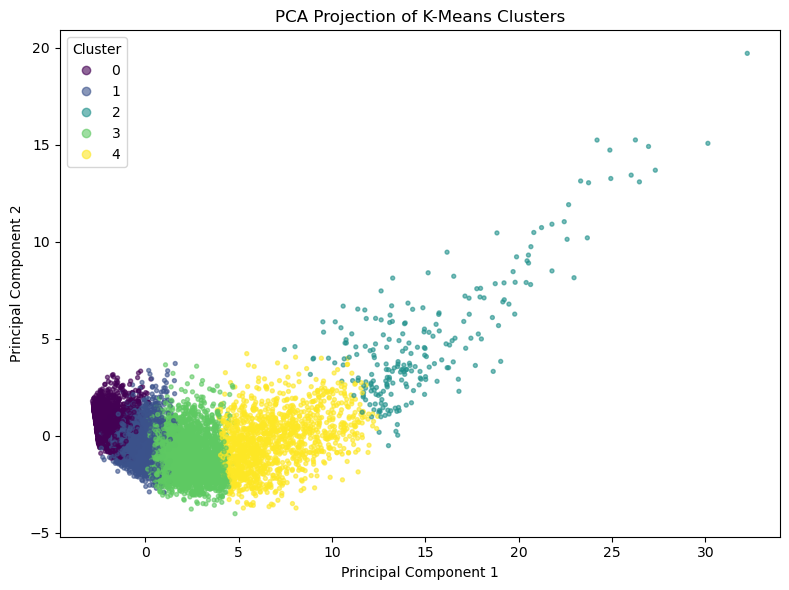

In [31]:
# Randomly sample 20,000 points
sample_size = 20000
idx = np.random.RandomState(42).choice(
    len(X),
    size=min(sample_size, len(X)),
    replace=False
)

X_sample = X[idx]
labels_sample = labels[idx]

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_sample,
    s=8,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of K-Means Clusters")

plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()